# EDA Lanjutan — Query Langsung dari PostgreSQL

Notebook ini menggunakan data dari SQL Views (`vw_credit_risk`, `vw_customer_summary`)
yang sudah dibuat di database `credit_risk_db`, bukan membaca ulang file CSV.

Tujuan:
- Membuktikan pipeline Python -> PostgreSQL -> SQL View benar-benar terpakai
- Visualisasi hasil analisis bisnis dari Milestone 14-15

In [3]:
import sys
from pathlib import Path

# Tambahkan root project ke sys.path supaya bisa import dari src/
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.queries import (
    get_default_rate_by_education,
    get_default_rate_by_occupation,
    get_default_rate_by_income_group,
    get_default_rate_by_age_group,
    get_avg_loan_by_default_status,
    get_default_rate_by_gender_ownership,
    get_feature_correlation,
)

sns.set_style("whitegrid")

In [4]:
## 1. Default Rate by Education
df_education = get_default_rate_by_education()
df_education

,NAME_EDUCATION_TYPE,total_customer,total_default,default_rate_pct
0,Lower secondary,3816,417.0,10.93
1,Secondary / secondary special,218391,19524.0,8.94
2,Incomplete higher,10277,872.0,8.48
3,Higher education,74863,4009.0,5.36
4,Academic degree,164,3.0,1.83


C:\Users\christovel kevin .m\AppData\Local\Temp\ipykernel_18760\972177235.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_education, x="default_rate_pct", y="NAME_EDUCATION_TYPE", palette="Reds_r")


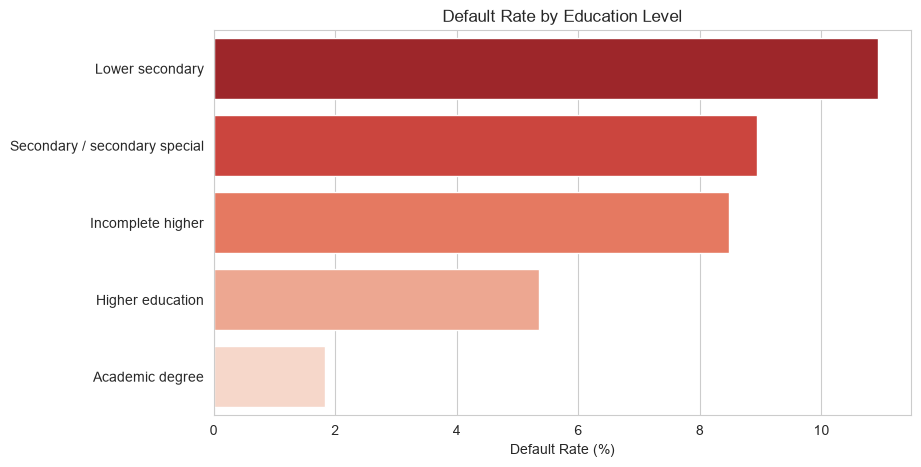

In [5]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df_education, x="default_rate_pct", y="NAME_EDUCATION_TYPE", palette="Reds_r")
plt.title("Default Rate by Education Level")
plt.xlabel("Default Rate (%)")
plt.ylabel("")
plt.show()

In [6]:
## 2. Default Rate by Occupation
df_occupation = get_default_rate_by_occupation()
df_occupation

,OCCUPATION_TYPE,total_customer,total_default,default_rate_pct
0,Low-skill Laborers,2093,359.0,17.15
1,Drivers,18603,2107.0,11.33
2,Waiters/barmen staff,1348,152.0,11.28
3,Security staff,6721,722.0,10.74
4,Laborers,55186,5838.0,10.58
5,Cooking staff,5946,621.0,10.44
6,Sales staff,32102,3092.0,9.63
7,Cleaning staff,4653,447.0,9.61
8,Realty agents,751,59.0,7.86
9,Secretaries,1305,92.0,7.05


C:\Users\christovel kevin .m\AppData\Local\Temp\ipykernel_18760\4186879661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_occupation, x="default_rate_pct", y="OCCUPATION_TYPE", palette="Reds_r")


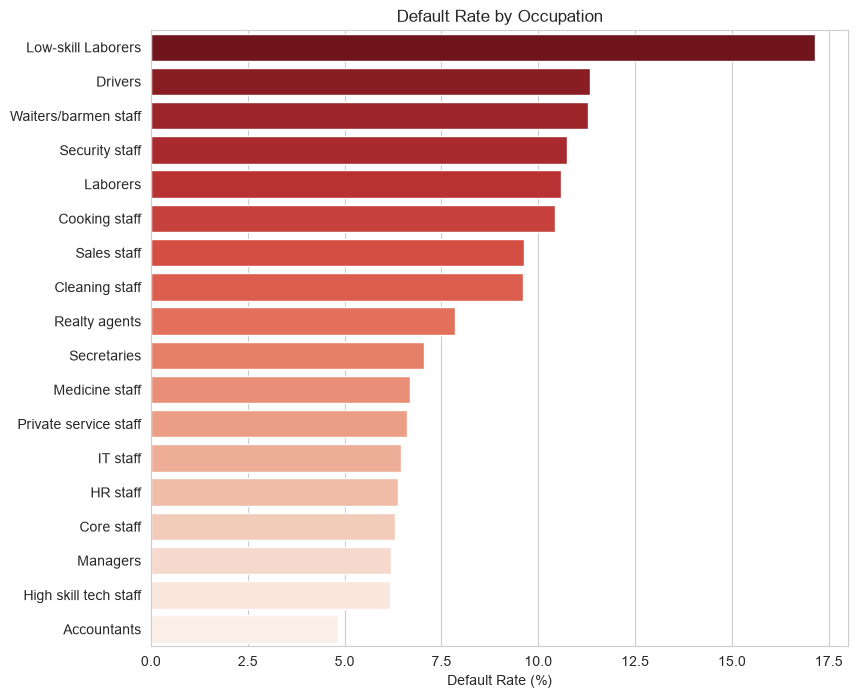

In [7]:
plt.figure(figsize=(9, 8))
sns.barplot(data=df_occupation, x="default_rate_pct", y="OCCUPATION_TYPE", palette="Reds_r")
plt.title("Default Rate by Occupation")
plt.xlabel("Default Rate (%)")
plt.ylabel("")
plt.show()

In [8]:
## 3. Default Rate by Income Group
df_income = get_default_rate_by_income_group()
df_income

,income_group,total_customer,total_default,default_rate_pct
0,1. < 100K,63698,5225.0,8.20
1,2. 100K - 200K,155898,13326.0,8.55
2,3. 200K - 300K,65176,4921.0,7.55
3,4. 300K - 500K,20037,1207.0,6.02
4,5. > 500K,2702,146.0,5.40


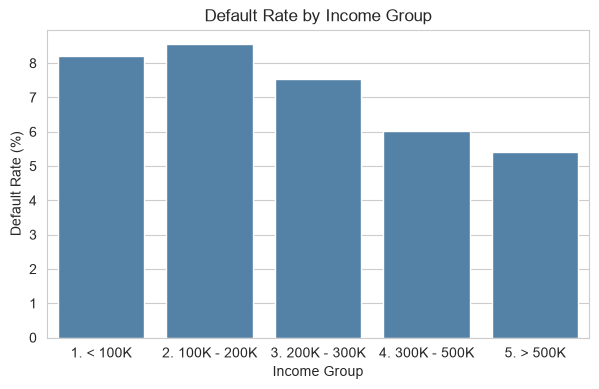

In [9]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df_income, x="income_group", y="default_rate_pct", color="steelblue")
plt.title("Default Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")
plt.show()

In [10]:
## 4. Default Rate by Age Group
df_age = get_default_rate_by_age_group()
df_age

,age_group,total_customer,total_default,default_rate_pct
0,1. < 25,11923,1474.0,12.36
1,2. 25 - 34,72152,7706.0,10.68
2,3. 35 - 44,84231,7085.0,8.41
3,4. 45 - 54,70042,4951.0,7.07
4,5. 55 - 64,60767,3291.0,5.42
5,6. 65+,8396,318.0,3.79


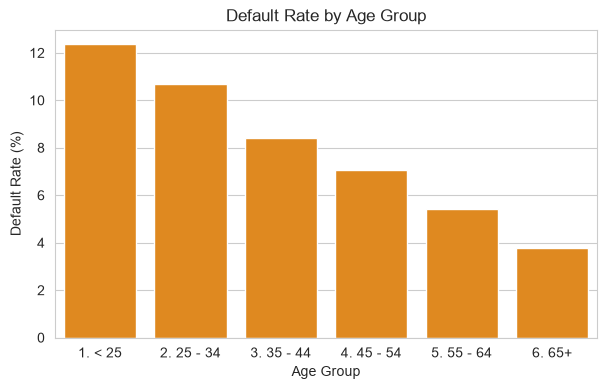

In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df_age, x="age_group", y="default_rate_pct", color="darkorange")
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.show()

In [12]:
## 5. Average Loan Amount by Default Status
df_loan = get_avg_loan_by_default_status()
df_loan

,TARGET,total_customer,avg_credit_amount,avg_income,avg_credit_income_ratio
0,0,282686,602648.0,169078.0,3.96
1,1,24825,557779.0,165612.0,3.89


In [13]:
## 6. Default Rate by Gender & Asset Ownership
df_gender_ownership = get_default_rate_by_gender_ownership()
df_gender_ownership

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,total_customer,default_rate_pct
0,M,N,N,15589,12.71
1,M,N,Y,29844,12.40
2,M,Y,Y,40049,8.54
3,M,Y,N,19577,7.93
4,F,N,N,46383,7.74
5,F,N,Y,111106,7.18
6,F,Y,Y,32309,5.83
7,F,Y,N,12650,5.68
8,XNA,N,Y,2,0.00
9,XNA,Y,Y,2,0.00


In [14]:
## 7. Korelasi Fitur Numerik vs TARGET
df_corr = get_feature_correlation()
df_corr

,feature,correlation
0,EXT_SOURCE_3,-0.178919
1,EXT_SOURCE_2,-0.160472
2,EXT_SOURCE_1,-0.155317
3,age_years,-0.078237
4,employment_years,-0.074962
5,AMT_CREDIT,-0.030369
6,CNT_CHILDREN,0.019187
7,annuity_income_ratio,0.014265
8,AMT_ANNUITY,-0.012817
9,CNT_FAM_MEMBERS,0.009308


C:\Users\christovel kevin .m\AppData\Local\Temp\ipykernel_18760\1269728938.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_corr, x="correlation", y="feature", palette=colors)


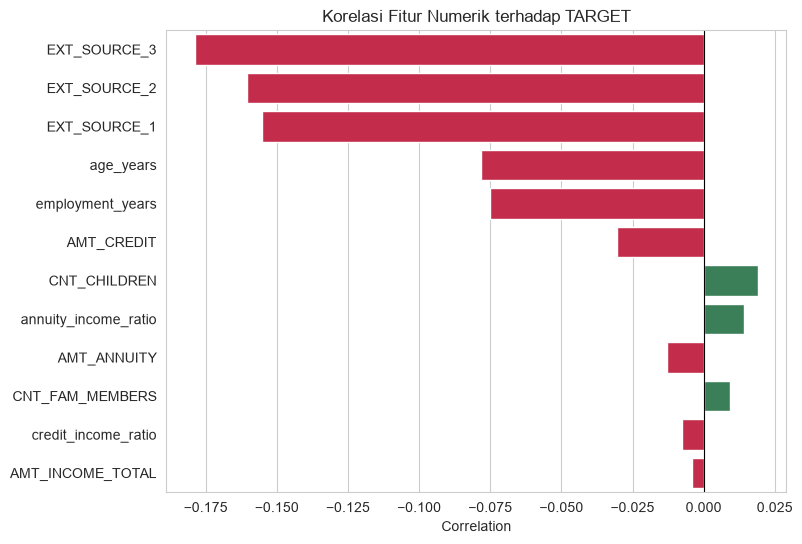

In [15]:
plt.figure(figsize=(8, 6))
colors = ["crimson" if x < 0 else "seagreen" for x in df_corr["correlation"]]
sns.barplot(data=df_corr, x="correlation", y="feature", palette=colors)
plt.title("Korelasi Fitur Numerik terhadap TARGET")
plt.xlabel("Correlation")
plt.ylabel("")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()